In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as la

%precision 4

'%.4f'

1\. **PCA on 3D dataset**

* Generate a dataset with 3 features each with N entries (N being ${\cal O}(1000)$). With $N(\mu,\sigma)$ the normali distribution with mean $\mu$ and $\sigma$  standard deviation, generate the 3 variables $x_{1,2,3}$ such that:
    * $x_1$ is distributed as $N(0,1)$
    * $x_2$ is distributed as $x_1+N(0,3)$
    * $x_3$ is given by $2x_1+x_2$
* Find the eigenvectors and eigenvalues of the covariance matrix of the dataset
* Find the eigenvectors and eigenvalues using SVD. Check that the two procedures yield to same result
* What percent of the total dataset's variability is explained by the principal components? Given how the dataset was constructed, do these make sense? Reduce the dimensionality of the system so that at least 99% of the total variability is retained.
* Redefine the data in the basis yielded by the PCA procedure
* Plot the data points in the original and the new coordiantes as a set of scatter plots. Your final figure should have 2 rows of 3 plots each, where the columns show the (0,1), (0,2) and (1,2) proejctions.


In [2]:
N = 1000
x1 = np.random.normal(loc=0, scale=1, size=N)
x2 = x1 + np.random.normal(loc=0, scale=3, size=N)
x3 = 2 * x1 + x2

X = np.column_stack((x1, x2, x3)).T #(3 x 1000)

In [3]:
cov = np.cov(X)
print(f"Covariance Matrix:= \n {cov}")

l, V = la.eig(cov)
print(f"Eigenvalues matrix:= \n {np.diag(np.real(l))}")
print(f"Eigenvectors matrix:= \n {V}")

Covariance Matrix:= 
 [[ 0.9266  0.8453  2.6986]
 [ 0.8453  9.6558 11.3464]
 [ 2.6986 11.3464 16.7436]]
Eigenvalues matrix:= 
 [[2.5380e+01 0.0000e+00 0.0000e+00]
 [0.0000e+00 1.4391e-15 0.0000e+00]
 [0.0000e+00 0.0000e+00 1.9463e+00]]
Eigenvectors matrix:= 
 [[-0.1089 -0.8165  0.567 ]
 [-0.5855 -0.4082 -0.7004]
 [-0.8033  0.4082  0.4336]]


In [4]:
# if we want to get them via SVD

U, D, Vt = la.svd(cov)
print(f"Eigenvalues matrix:= \n {np.diag(D)}")
print(f"Eigenvectors matrix:= \n {np.real(U)}")
# we get the same result with a permutation

Eigenvalues matrix:= 
 [[2.5380e+01 0.0000e+00 0.0000e+00]
 [0.0000e+00 1.9463e+00 0.0000e+00]
 [0.0000e+00 0.0000e+00 1.8990e-15]]
Eigenvectors matrix:= 
 [[-0.1089  0.567  -0.8165]
 [-0.5855 -0.7004 -0.4082]
 [-0.8033  0.4336  0.4082]]


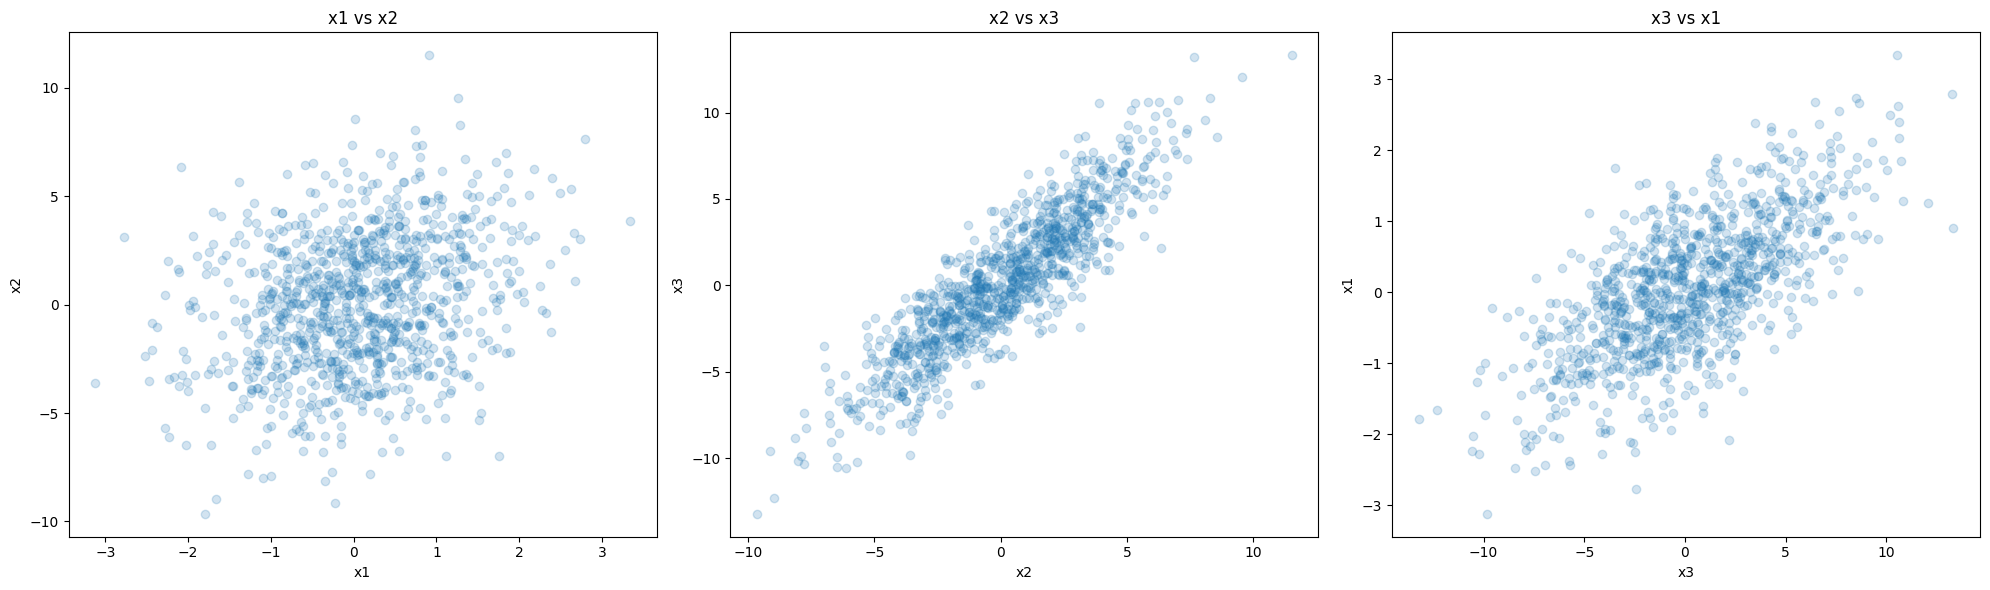

In [5]:
plt.figure(figsize=(20,6))

plt.subplot(131)
plt.title('x1 vs x2')
plt.scatter(X[0,:], X[1,:], alpha=0.2)
plt.xlabel('x1')
plt.ylabel('x2')

plt.subplot(132)
plt.title('x2 vs x3')
plt.scatter(X[1,:], X[2,:], alpha=0.2)
plt.xlabel('x2')
plt.ylabel('x3')

plt.subplot(133)
plt.title('x3 vs x1')
plt.scatter(X[2,:], X[0,:], alpha=0.2)
plt.xlabel('x3')
plt.ylabel('x1')

plt.tight_layout()
plt.show()

In [6]:
# rotate the dataset in the principal component system
Xp = np.dot(V.T, X)
# calculate the covariance matrix
covp = np.cov(Xp) # can be approximated as diagonal
print(f"Covariance Matrix projected in principal components:= \n {covp} \n")
# lp, Vp = la.eig(covp)
# print(f"Covariance projected in principal components eigenvalues := \n {np.diag(np.real(lp))}")
# print(f"Covariance projected in principal components eigenvectors:= \n {Vp}")

tr_covp = covp.trace()
print(f"Variability of xp1:= {covp[0,0] * 100 / tr_covp } %")
print(f"Variability of xp2:= {covp[1,1] * 100 / tr_covp} % ")
print(f"Variability of xp3:= {covp[2,2] * 100 / tr_covp} %")

Covariance Matrix projected in principal components:= 
 [[ 2.5380e+01  2.0237e-15 -4.2471e-15]
 [ 2.0237e-15  4.2959e-30 -2.8315e-15]
 [-4.2471e-15 -2.8315e-15  1.9463e+00]] 

Variability of xp1:= 92.87736090133198 %
Variability of xp2:= 1.5720943431769314e-29 % 
Variability of xp3:= 7.122639098668025 %


In [7]:
#delete second component
Xpred = np.column_stack((Xp[0,:], np.zeros(N), Xp[2,:])).T
# now we rotate back to the original dataset variables
Xred = np.dot(V, Xpred) #reconstructed data

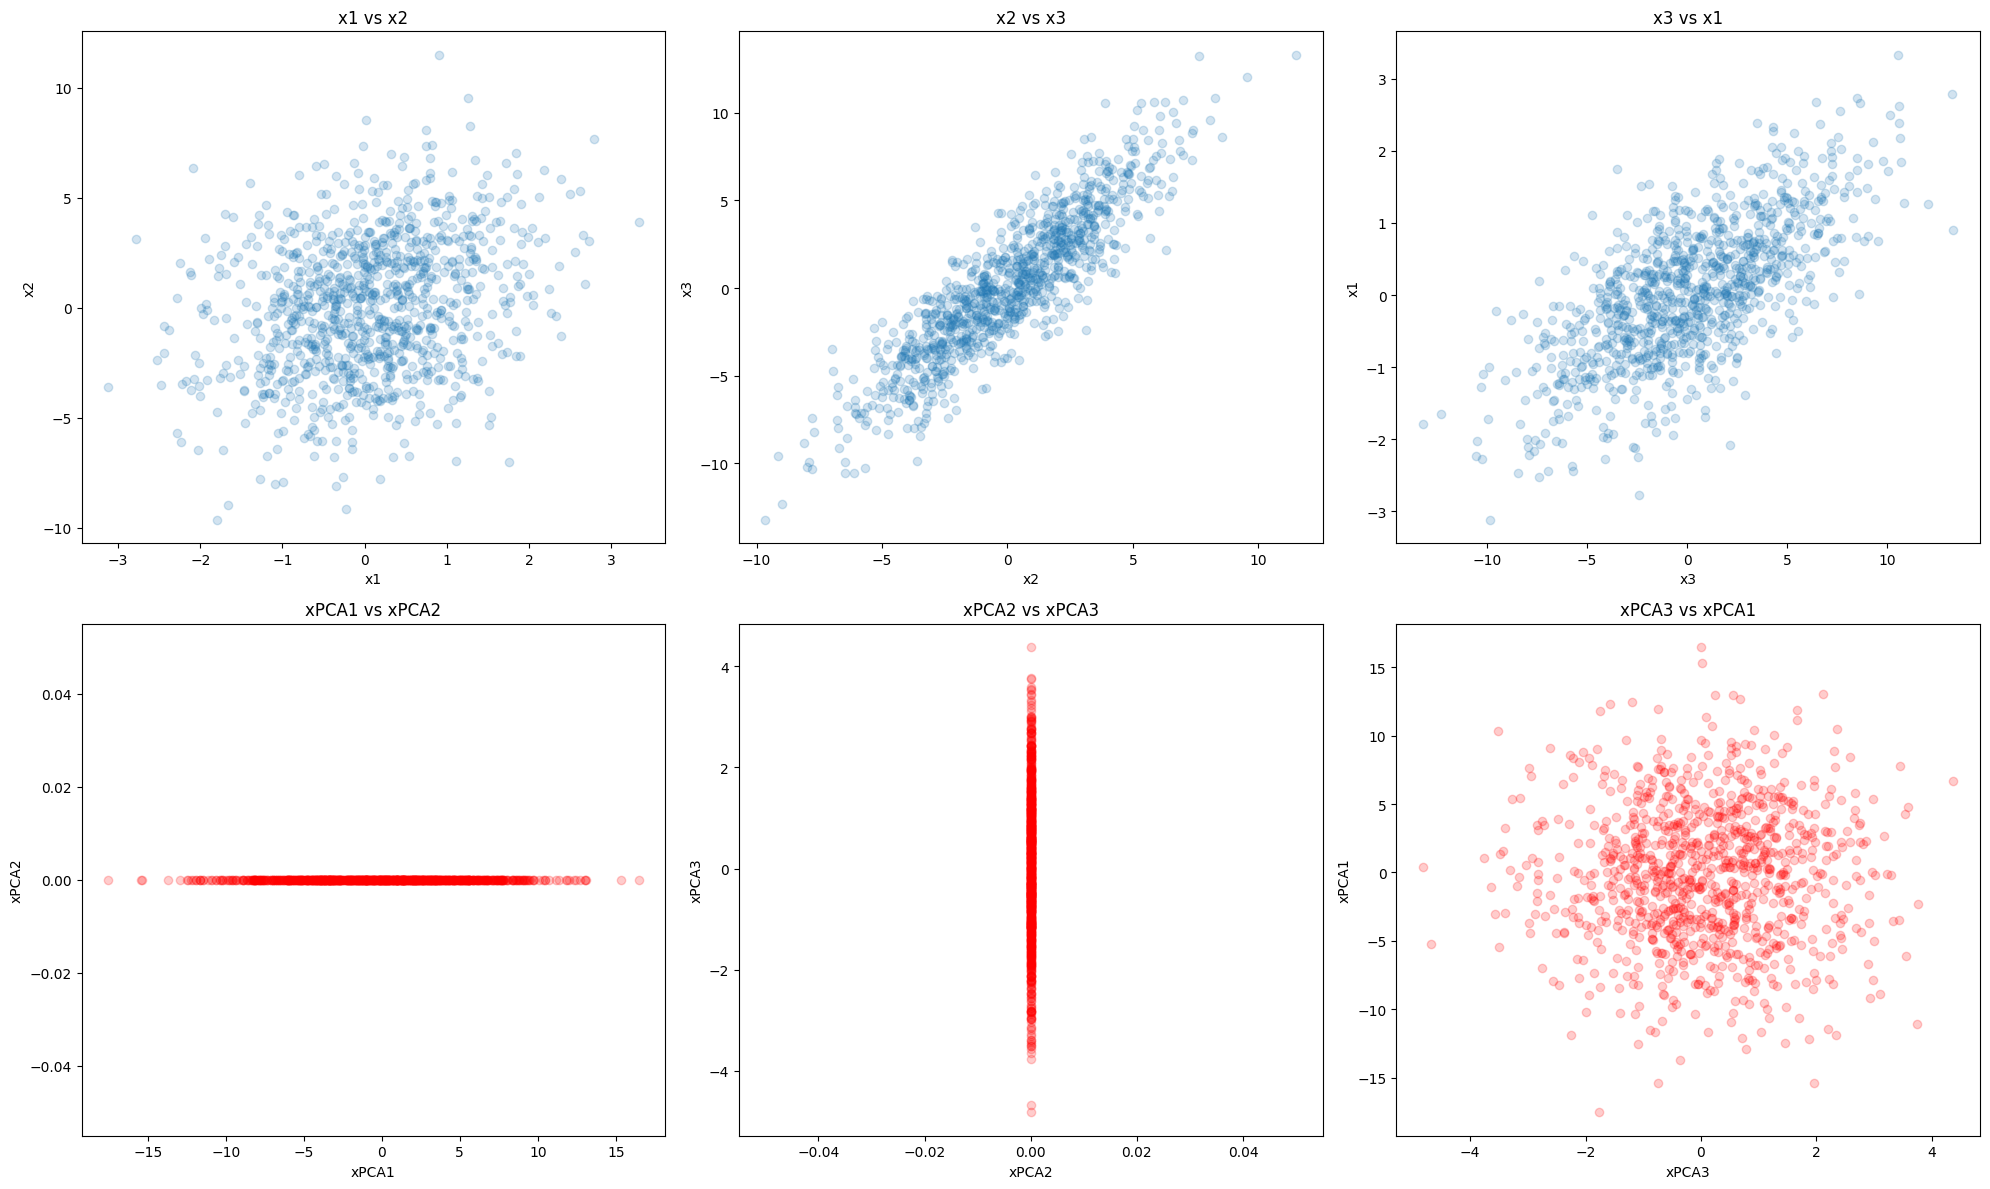

In [8]:
plt.figure(figsize=(20,12))

plt.subplot(231)
plt.title('x1 vs x2')
plt.scatter(X[0,:], X[1,:], alpha=0.2)
plt.xlabel('x1')
plt.ylabel('x2')

plt.subplot(232)
plt.title('x2 vs x3')
plt.scatter(X[1,:], X[2,:], alpha=0.2)
plt.xlabel('x2')
plt.ylabel('x3')

plt.subplot(233)
plt.title('x3 vs x1')
plt.scatter(X[2,:], X[0,:], alpha=0.2)
plt.xlabel('x3')
plt.ylabel('x1')

plt.subplot(234)
plt.title('xPCA1 vs xPCA2')
plt.scatter(Xpred[0,:], Xpred[1,:], alpha=0.2, c='r')
plt.xlabel('xPCA1')
plt.ylabel('xPCA2')

plt.subplot(235)
plt.title('xPCA2 vs xPCA3')
plt.scatter(Xpred[1,:], Xpred[2,:], alpha=0.2, c='r')
plt.xlabel('xPCA2')
plt.ylabel('xPCA3')

plt.subplot(236)
plt.title('xPCA3 vs xPCA1')
plt.scatter(Xpred[2,:], Xpred[0,:], alpha=0.2, c='r')
plt.xlabel('xPCA3')
plt.ylabel('xPCA1')

plt.tight_layout()
plt.show()

2\. **PCA on a nD dataset**

Start from the dataset you have genereted in the previous exercise and add uncorrelated random noise. Such noise should be represented by other 10 uncorrelated variables normal distributed, with standar deviation much smaller (say, a factor 50) than those used to generate the $x_1$ and $x_2$.

Repeat the PCA procedure and compare the results with what you obtained before

In [9]:
X = np.zeros((13, N))
X[0,:], X[1,:], X[2,:] = x1, x2, x3
for i in range(3, 13):
    sigma = np.random.randint(1, 4, size=1) / 50
    X[i, :] = np.random.normal(loc=0, scale=sigma, size=N)

In [10]:
cov = np.cov(X)
print(f"Covariance matrix of the dataset:= {cov}")
l, V = la.eig(cov)

Covariance matrix of the dataset:= [[ 9.2664e-01  8.4531e-01  2.6986e+00  4.3218e-05 -4.9148e-04  1.2227e-03
   2.0317e-04 -2.4934e-03 -8.1516e-04  2.4432e-04 -4.4807e-06 -9.8164e-04
  -1.7614e-03]
 [ 8.4531e-01  9.6558e+00  1.1346e+01 -1.1349e-02  2.8284e-03 -1.4534e-03
  -6.9419e-04 -6.0999e-03 -9.8720e-03 -2.2643e-03 -3.5967e-03 -9.9834e-03
  -2.5877e-03]
 [ 2.6986e+00  1.1346e+01  1.6744e+01 -1.1263e-02  1.8454e-03  9.9193e-04
  -2.8786e-04 -1.1087e-02 -1.1502e-02 -1.7756e-03 -3.6056e-03 -1.1947e-02
  -6.1105e-03]
 [ 4.3218e-05 -1.1349e-02 -1.1263e-02  3.2814e-03 -1.9764e-05 -7.7108e-05
  -1.8230e-05 -5.2910e-06  1.5934e-04  4.1265e-06 -1.1091e-05 -7.3622e-05
  -7.0927e-05]
 [-4.9148e-04  2.8284e-03  1.8454e-03 -1.9764e-05  4.2213e-04 -1.3002e-06
   1.2936e-05  2.7680e-05 -5.5520e-05 -1.8009e-06 -8.5465e-06 -3.7529e-05
  -9.2190e-07]
 [ 1.2227e-03 -1.4534e-03  9.9193e-04 -7.7108e-05 -1.3002e-06  1.6316e-03
   2.0366e-06  4.2034e-05 -6.6797e-05 -2.9006e-05  3.4859e-05  7.9151e-05
  

In [11]:
Xp = np.dot(V.T, X)
covp = np.cov(Xp)
print(f"Covariance matrix of the projected dataset:= {covp}")

Covariance matrix of the projected dataset:= [[ 2.5380e+01  7.1383e-15 -5.5033e-16 -1.0269e-15 -7.3882e-16  6.2324e-16
   1.2729e-15  2.8610e-15  1.5270e-14  4.5565e-18 -3.1117e-18  7.7793e-19
   2.6672e-18]
 [ 7.1383e-15  1.9464e+00  4.6120e-17  4.1786e-17 -9.0490e-17  1.3380e-16
  -2.0851e-17 -3.4896e-17 -2.8256e-15 -1.6670e-18 -3.0006e-18 -7.7793e-19
   2.7783e-19]
 [-5.5033e-16  4.6120e-17  3.8431e-03  1.2551e-17  2.4484e-18 -4.9750e-18
   2.4310e-20  3.3687e-19 -9.8785e-20  7.8141e-20 -8.6823e-20  2.2921e-19
  -2.0143e-19]
 [-1.0269e-15  4.1786e-17  1.2551e-17  3.7783e-03  1.0419e-18 -3.4139e-18
   2.0838e-19 -6.7375e-19  7.9982e-19 -2.0317e-19  1.7017e-19  1.7365e-20
   5.9040e-20]
 [-7.3882e-16 -9.0490e-17  2.4484e-18  1.0419e-18  3.5003e-03 -1.1079e-17
  -1.2238e-18  4.6537e-19  1.4987e-18 -4.3411e-19 -4.8035e-19  1.7191e-19
   2.7783e-20]
 [ 6.2324e-16  1.3380e-16 -4.9750e-18 -3.4139e-18 -1.1079e-17  3.2199e-03
  -9.5853e-19  2.7783e-19 -3.6149e-18  9.0296e-20 -3.7508e-19  1.4

In [12]:
tr_covp = covp.trace()
for i in range(13):
    print(f"Variability of xp{i}:= {covp[i,i] * 100 / tr_covp } %")

Variability of xp0:= 92.8119181620332 %
Variability of xp1:= 7.117664641453715 %
Variability of xp2:= 0.01405387973737114 %
Variability of xp3:= 0.013816860837105219 %
Variability of xp4:= 0.012800204001792641 %
Variability of xp5:= 0.011774894863954817 %
Variability of xp6:= 0.0062327367907251355 %
Variability of xp7:= 0.005860820650100446 %
Variability of xp8:= 4.874004550799678e-29 %
Variability of xp9:= 0.0015611985200751051 %
Variability of xp10:= 0.001513259768847722 %
Variability of xp11:= 0.0013910263167589627 %
Variability of xp12:= 0.0014123150263562656 %


In [13]:
Xpred = np.zeros((13, N))
Xpred[0,:], Xpred[1, :] = Xp[0], Xp[1] # we discard others
Xred = np.dot(V, Xpred)

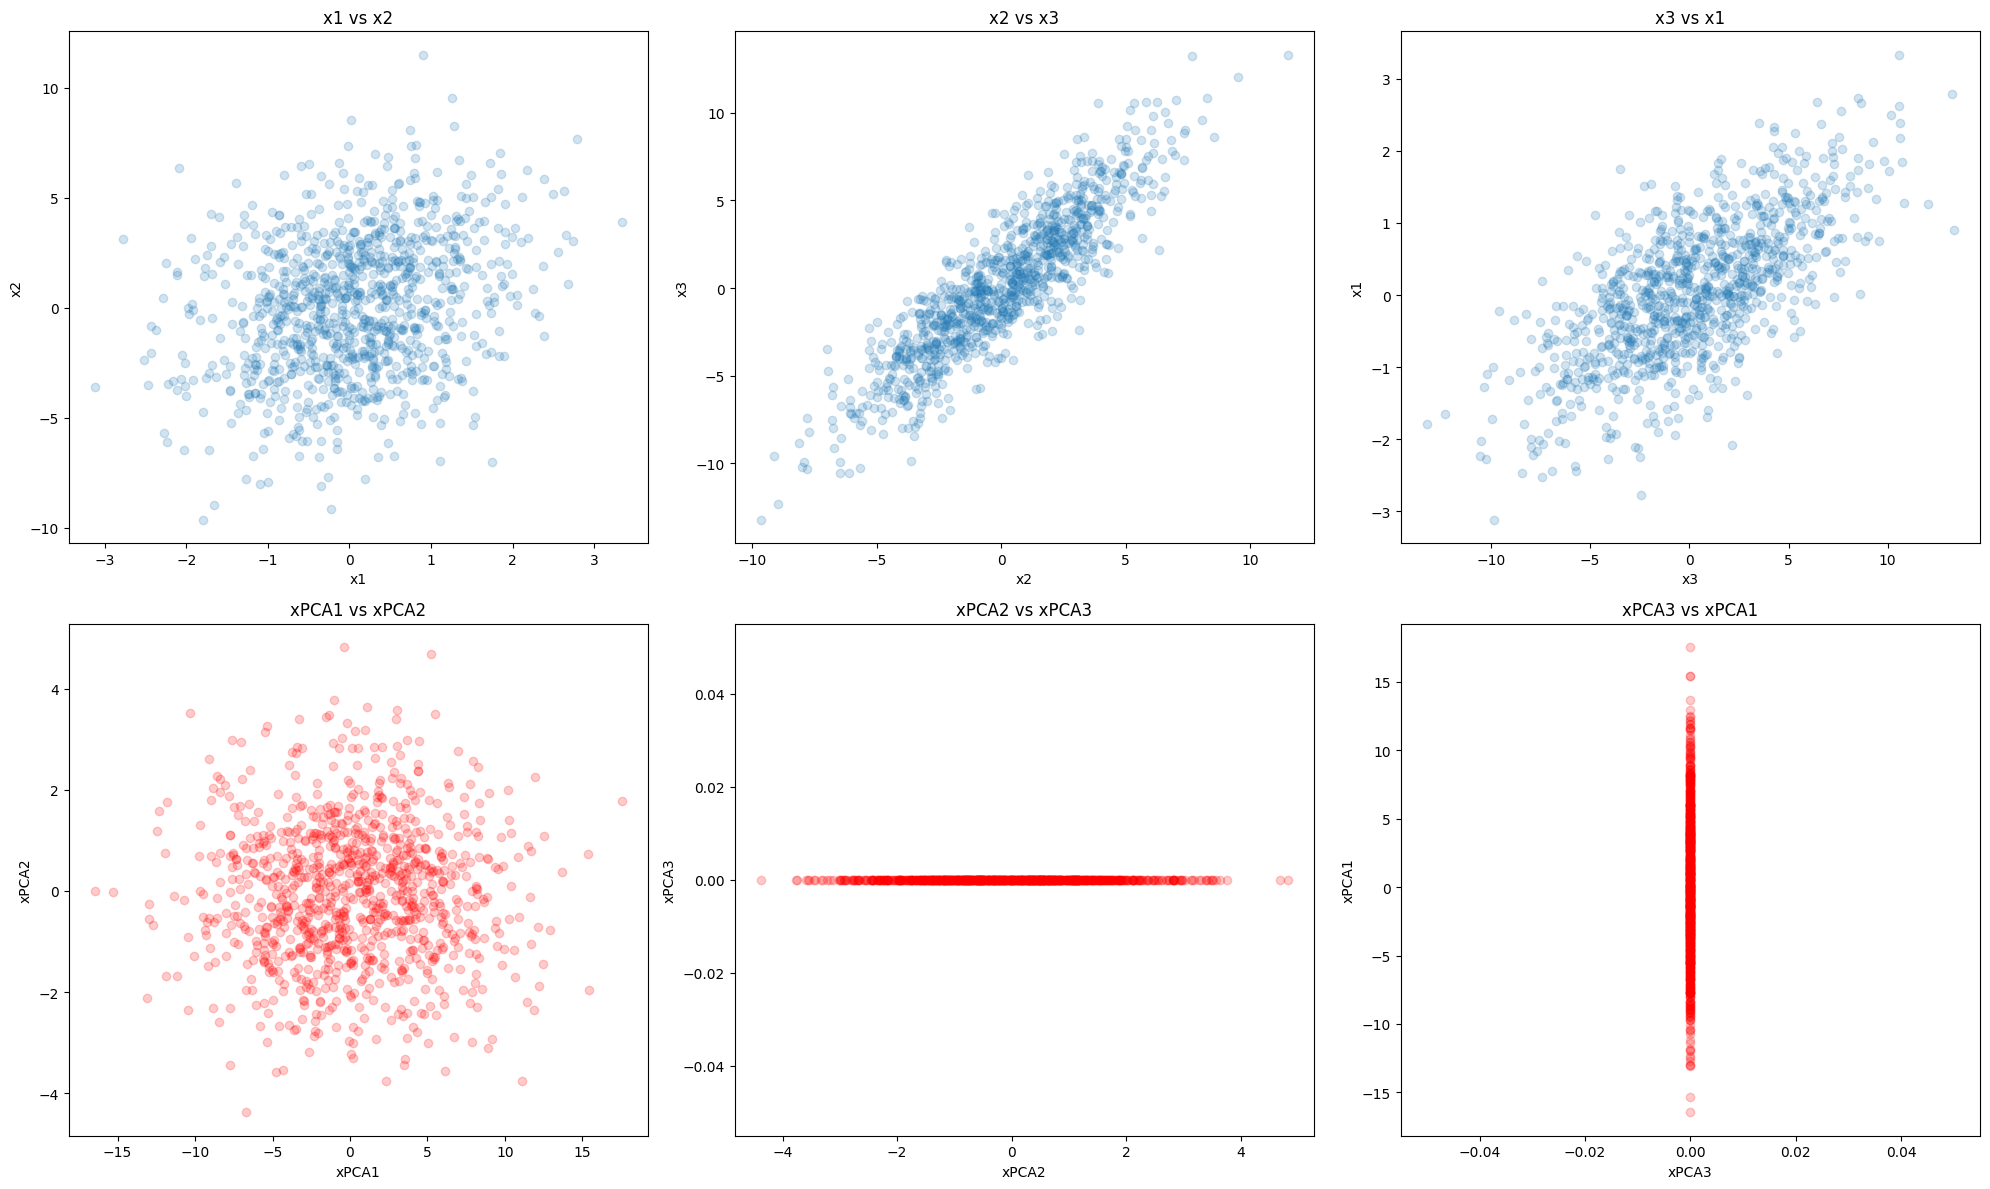

In [14]:
plt.figure(figsize=(20,12))

plt.subplot(231)
plt.title('x1 vs x2')
plt.scatter(X[0,:], X[1,:], alpha=0.2)
plt.xlabel('x1')
plt.ylabel('x2')

plt.subplot(232)
plt.title('x2 vs x3')
plt.scatter(X[1,:], X[2,:], alpha=0.2)
plt.xlabel('x2')
plt.ylabel('x3')

plt.subplot(233)
plt.title('x3 vs x1')
plt.scatter(X[2,:], X[0,:], alpha=0.2)
plt.xlabel('x3')
plt.ylabel('x1')

plt.subplot(234)
plt.title('xPCA1 vs xPCA2')
plt.scatter(Xpred[0,:], Xpred[1,:], alpha=0.2, c='r')
plt.xlabel('xPCA1')
plt.ylabel('xPCA2')

plt.subplot(235)
plt.title('xPCA2 vs xPCA3')
plt.scatter(Xpred[1,:], Xpred[2,:], alpha=0.2, c='r')
plt.xlabel('xPCA2')
plt.ylabel('xPCA3')

plt.subplot(236)
plt.title('xPCA3 vs xPCA1')
plt.scatter(Xpred[2,:], Xpred[0,:], alpha=0.2, c='r')
plt.xlabel('xPCA3')
plt.ylabel('xPCA1')

plt.tight_layout()
plt.show()